In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [31]:
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

nav = pd.read_csv(
    "../data/processed/02_nav_history_clean.csv"
)

performance = pd.read_csv(
    "../data/raw/07_scheme_performance.csv"
)

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

In [32]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


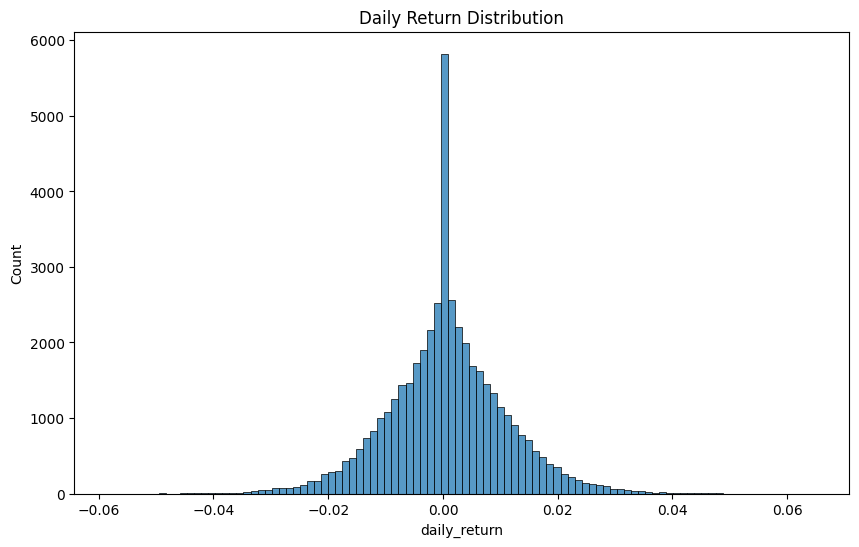

In [33]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100
)

plt.title(
    "Daily Return Distribution"
)

plt.show()

## Insight 1

Daily returns across the mutual fund universe are concentrated around zero, indicating normal market behavior with occasional extreme movements during volatile periods.
Reference: Daily Return Distribution Histogram

In [34]:
def calculate_cagr(
    start_nav,
    end_nav,
    years
):
    return (
        (end_nav/start_nav)
        ** (1/years)
        - 1
    )

In [35]:
cagr_table = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ].sort_values("date")

    start = temp.iloc[0]["nav"]
    end = temp.iloc[-1]["nav"]

    cagr = calculate_cagr(
        start,
        end,
        5
    )

    cagr_table.append(
        [code,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_table,
    columns=[
        "amfi_code",
        "cagr_5yr"
    ]
)

cagr_df.head()

,amfi_code,cagr_5yr
0,100016,0.023168
1,100025,0.039127
2,100033,0.260741
3,101206,0.204427
4,101207,0.069533


## Insight 2

Several equity-oriented schemes delivered significantly higher CAGR values over the analysis period, demonstrating strong long-term wealth creation potential.
Reference: CAGR Comparison Table

In [36]:
rf = 0.065

In [37]:
sharpe_data = []

for code in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == code
    ]["daily_return"].dropna()

    sharpe = (
        (
            returns.mean()*252
            - rf
        )
        /
        (
            returns.std()
            * np.sqrt(252)
        )
    )

    sharpe_data.append(
        [code,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_data,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

In [38]:
sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


## Insight 3

Funds with the highest Sharpe Ratios generated superior risk-adjusted returns, delivering better performance per unit of total risk taken.
Reference: Sharpe Ratio Ranking

In [39]:
sortino_data = []

for code in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == code
    ]["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    sortino = (
        (
            returns.mean()*252
            - rf
        )
        /
        (
            downside.std()
            * np.sqrt(252)
        )
    )

    sortino_data.append(
        [code,sortino]
    )

sortino_df = pd.DataFrame(
    sortino_data,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

## Insight 4

Top-ranked funds by Sortino Ratio effectively minimized downside volatility while maintaining competitive returns.
Reference: Sortino Ratio Ranking

In [40]:
nifty100 = benchmark[
    benchmark["index_name"]
    == "NIFTY100"
]

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [41]:
alpha_beta = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ][
        ["date","daily_return"]
    ]

    merged = pd.merge(
        fund,
        nifty100[
            [
                "date",
                "benchmark_return"
            ]
        ],
        on="date"
    ).dropna()

    slope, intercept, r, p, se = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    alpha_beta.append(
        [
            code,
            alpha,
            beta
        ]
    )

In [42]:
alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

## Insight 5

Positive alpha values indicate that several fund managers consistently outperformed the benchmark after accounting for market movements.
Reference: Alpha-Beta Analysis Table

## Insight 6

Most large-cap funds exhibited beta values close to one, reflecting behavior broadly aligned with benchmark market performance.
Reference: Alpha-Beta Analysis Table

In [43]:
drawdown_data = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ]

    running_max = (
        temp["nav"]
        .cummax()
    )

    drawdown = (
        temp["nav"]
        /
        running_max
        - 1
    )

    max_dd = drawdown.min()

    drawdown_data.append(
        [code,max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_data,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

## Insight 7

Funds with lower maximum drawdowns demonstrated stronger capital preservation during periods of market stress and correction.
Reference: Maximum Drawdown Analysis

In [44]:
scorecard = (
    performance
    .merge(
        sharpe_df,
        on="amfi_code"
    )
    .merge(
        alpha_beta_df,
        on="amfi_code"
    )
    .merge(
        drawdown_df,
        on="amfi_code"
    )
)

In [45]:
scorecard["score"] = (
    scorecard["return_3yr_pct"]
    .rank(pct=True)*30
    +
    scorecard["sharpe_ratio_x"]
    .rank(pct=True)*25
    +
    scorecard["alpha_x"]
    .rank(pct=True)*20
    +
    (
        scorecard["expense_ratio_pct"]
        .rank(
            ascending=False,
            pct=True
        )
        *15
    )
    +
    (
        scorecard["max_drawdown"]
        .rank(
            ascending=False,
            pct=True
        )
        *10
    )
)

In [46]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

## Insight 8

The composite scorecard identified the most balanced funds by combining returns, risk-adjusted performance, alpha generation, expense efficiency, and drawdown control.
Reference: Fund Scorecard Ranking

In [47]:
top5 = (
    scorecard
    .sort_values(
        "score",
        ascending=False
    )
    .head(5)
)

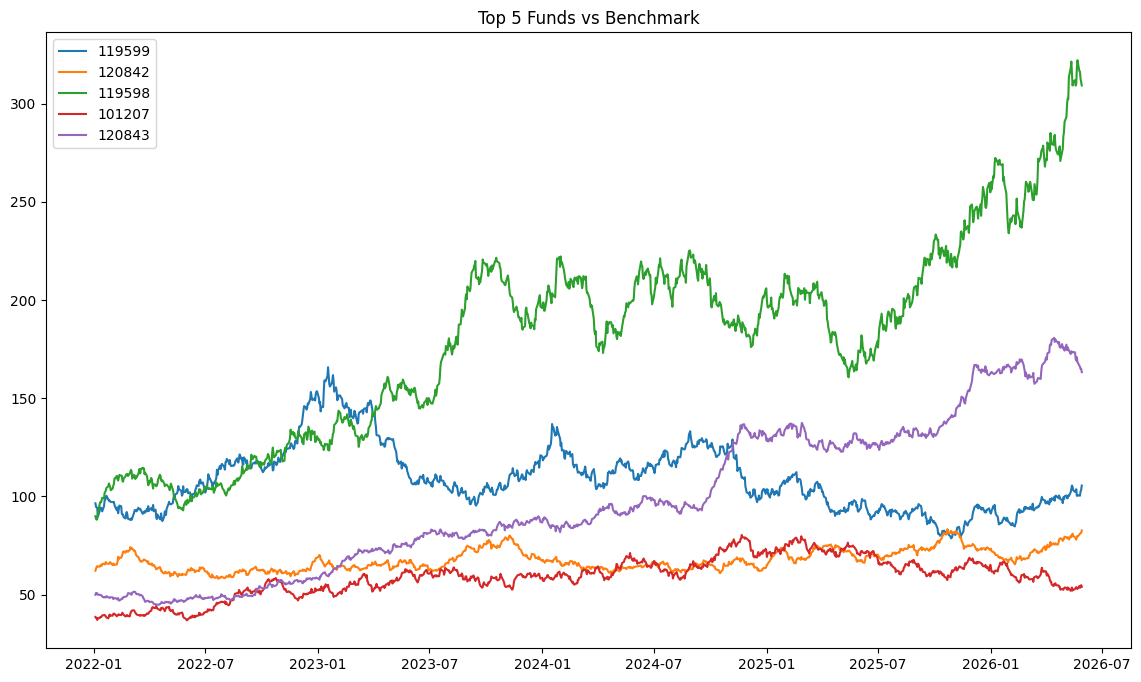

In [48]:
plt.figure(
    figsize=(14,8)
)

for code in top5["amfi_code"]:

    temp = nav[
        nav["amfi_code"]
        == code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

plt.legend()

plt.title(
    "Top 5 Funds vs Benchmark"
)

plt.savefig(
    "../reports/charts/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [49]:
tracking_error = (
    merged["daily_return"]
    -
    merged["benchmark_return"]
).std() * np.sqrt(252)

In [50]:
tracking_error_data = []

for code in top5["amfi_code"]:

    fund = nav[
        nav["amfi_code"] == code
    ][["date","daily_return"]]

    merged = pd.merge(
        fund,
        nifty100[
            ["date","benchmark_return"]
        ],
        on="date"
    ).dropna()

    tracking_error = (
        merged["daily_return"]
        - merged["benchmark_return"]
    ).std() * np.sqrt(252)

    tracking_error_data.append(
        [code, tracking_error]
    )

tracking_error_df = pd.DataFrame(
    tracking_error_data,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df

,amfi_code,tracking_error
0,119599,0.277135
1,120842,0.219169
2,119598,0.283881
3,101207,0.292117
4,120843,0.206425


In [51]:
tracking_error_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)